# **Project Name** - DeepCSAT: E-Commerce Customer Satisfaction Score Prediction (EDA)


##### **Project Type** - EDA / Classification
##### **Contribution** - Individual
##### **Github Link -** https://github.com/mirohit/-E-Commerce-Customer-Satisfaction-Score-Predictor.git

# **Project Summary -**

This project analyzes one month of customer support interaction data from an e-commerce platform called "Shopzilla" to understand what drives Customer Satisfaction (CSAT) scores. The dataset has 85,907 records and 20 columns covering the support channel used, issue category and sub-category, customer text feedback, order details, timestamps for issue reporting and resolution, agent/supervisor/manager info, agent tenure and shift, and the CSAT score (1-5) given by the customer after the interaction.

The goal of this EDA phase is to understand the data quality, structure, and relationships well enough to prepare it for a downstream Artificial Neural Network (ANN) model that will predict CSAT scores. We started by inspecting the shape, datatypes, duplicate rows, and missing values. A key finding is that several columns are very sparse: `connected_handling_time` is missing in 99.7% of rows, `order_date_time` in about 80%, and `Customer_City`, `Product_category`, and `Item_price` are each missing in roughly 80% of rows. `Customer Remarks` (the free-text feedback) is missing in about 67% of rows. These gaps are not random noise to be casually imputed away — they reflect real gaps in how Shopzilla's systems capture data across channels (for example, Outcall interactions rarely have order or price data attached), so we treat missingness itself as informative wherever it is high.

The target variable, CSAT Score, is heavily imbalanced: about 69% of all interactions were rated 5 (very satisfied), while scores 2 and 3 together make up less than 5% of the data. Scores 1 and 4 are the next most common. This imbalance is an important and honest finding — it tells us that a naive model could get reasonable-looking accuracy just by always predicting 5, so evaluation later needs to look beyond plain accuracy (e.g., per-class precision/recall, macro F1, confusion matrix) rather than accuracy alone.

During data wrangling we parsed the three timestamp columns (`Issue_reported at`, `issue_responded`, `Survey_response_Date`) into proper datetime objects and engineered a `response_time_minutes` feature (time between issue reported and issue responded), which is a strong operational signal — long response times are a plausible driver of low satisfaction. We also engineered a `has_remarks` flag and a `remarks_length` feature from the free-text feedback, since the mere presence and length of a customer's written complaint is informative even before any NLP is applied to its content. Duplicate rows were checked and removed if found.

We then explored 15 visualizations covering the target distribution, channel and category-wise CSAT patterns, response time effects, agent tenure/shift effects, text feedback patterns, and a correlation heatmap and pairplot of the numeric/engineered features. Each chart is accompanied by reasoning for why that chart type was chosen, the insight extracted, and its business relevance.

Overall, the analysis shows that response time, presence/length of written feedback, and interaction category are the features most likely to carry predictive signal for CSAT, while several columns (`connected_handling_time`, raw order timestamps) are too sparse to be useful in their raw form. These findings directly inform the feature engineering and preprocessing choices for the ANN modeling notebook that follows.

# **GitHub Link -**

https://github.com/mirohit/-E-Commerce-Customer-Satisfaction-Score-Predictor.git

# **Problem Statement**


**Predict the Customer Satisfaction (CSAT) score (1 to 5) a customer will give after a support interaction on the Shopzilla e-commerce platform, using details of the interaction such as channel, category, response time, agent information, and customer feedback text, so that support quality issues can be identified and acted on without waiting for every customer to fill a survey.**

#### **Define Your Business Objective?**

E-commerce companies rely on post-interaction CSAT surveys to measure service quality, but not every customer responds to a survey, and by the time enough responses come in, the moment to fix a bad interaction has often passed. The business objective is to build a predictive system that estimates CSAT score directly from interaction data (channel, category, response time, agent tenure, remarks, etc.), enabling near real-time flagging of likely-dissatisfied customers so supervisors can intervene early, and enabling data-driven decisions on staffing, training, and process changes that improve satisfaction at scale.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [28]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)


### Dataset Loading

In [29]:
# Load Dataset
df = pd.read_csv(r"C:\Users\Rohit Sagar Chavan\Music\ML Engineering\DeepCSAT E-Commerce Customer Satisfaction Score Prediction (EDA)\EDA\Input File\eCommerce_Customer_support_data.csv")


### Dataset First View

In [30]:
# Dataset First Look
df.head()


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [31]:
# Dataset Rows & Columns count
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Number of rows: 85907
Number of columns: 20


### Dataset Information

In [32]:
# Dataset Info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [33]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


#### Missing Values/Null Values

In [34]:
# Missing Values/Null Values Count
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_df


,Missing Count,Missing %
connected_handling_time,85665,99.72
Customer_City,68828,80.12
Product_category,68711,79.98
Item_price,68701,79.97
order_date_time,68693,79.96
Customer Remarks,57165,66.54
Order_id,18232,21.22
Unique id,0,0.00
Sub-category,0,0.00
category,0,0.00


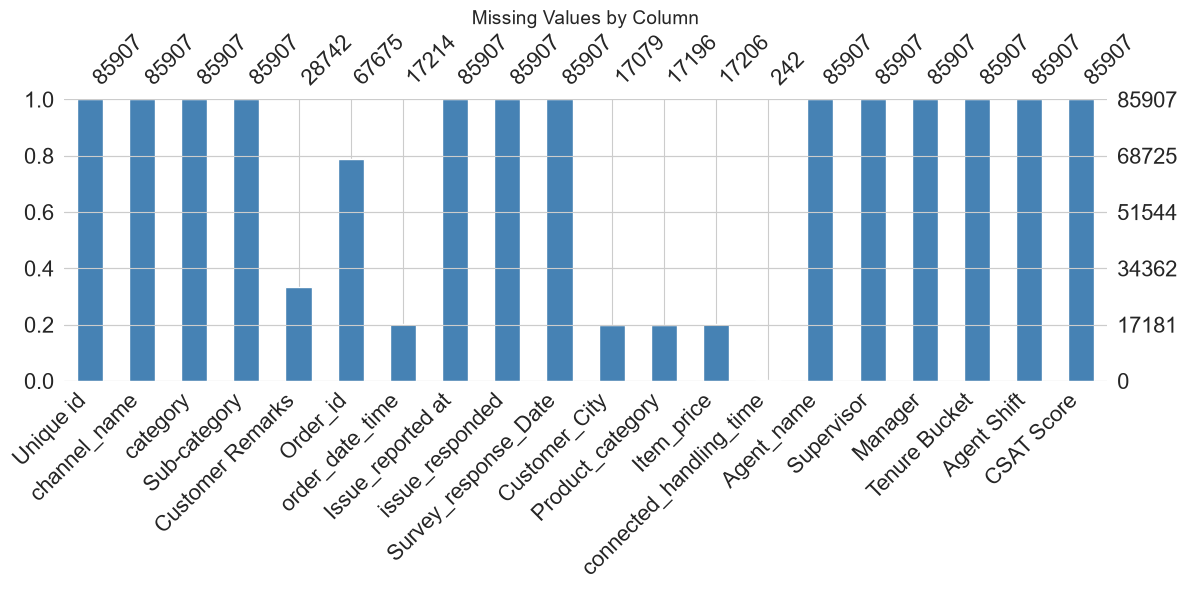

In [35]:
# Visualizing the missing values
plt.figure(figsize=(12, 6))
msno.bar(df, color='steelblue', figsize=(12, 6))
plt.title('Missing Values by Column', fontsize=14)
plt.tight_layout()
plt.show()


### What did you know about your dataset?

The dataset has 85,907 rows and 20 columns, with no fully duplicate rows. Data quality is uneven across columns: `connected_handling_time` is missing in about 99.7% of records (effectively unusable), `order_date_time` is missing in about 80%, and `Customer_City`, `Product_category`, and `Item_price` are each missing in roughly 80% of rows — these are likely only captured for certain channels/interaction types (e.g., order-linked issues). `Customer Remarks` is missing in about 67% of rows, meaning most customers did not leave written feedback. `Order_id` is missing in about 21% of rows. All other columns (channel, category, sub-category, timestamps for issue reported/responded, agent/supervisor/manager names, tenure bucket, agent shift, and the CSAT Score target) are fully populated. This tells us the reliable, fully-populated columns (channel, category, sub-category, response timestamps, agent info) will form the backbone of the model, while the sparse columns will need a missing-as-a-category strategy or be dropped.

## ***2. Understanding Your Variables***

In [36]:
# Dataset Columns
df.columns.tolist()


['Unique id',
 'channel_name',
 'category',
 'Sub-category',
 'Customer Remarks',
 'Order_id',
 'order_date_time',
 'Issue_reported at',
 'issue_responded',
 'Survey_response_Date',
 'Customer_City',
 'Product_category',
 'Item_price',
 'connected_handling_time',
 'Agent_name',
 'Supervisor',
 'Manager',
 'Tenure Bucket',
 'Agent Shift',
 'CSAT Score']

In [37]:
# Dataset Describe
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unique id,85907,85907,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel_name,85907,3,Inbound,68142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,85907,12,Returns,44097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-category,85907,57,Reverse Pickup Enquiry,22389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Remarks,28742,18231,Good,1390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_id,67675,67675,c27c9bb4-fa36-4140-9f1f-21009254ffdb,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date_time,17214,13766,09/08/2023 11:55,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Issue_reported at,85907,30923,13/08/2023 10:40,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
issue_responded,85907,30262,28/08/2023 00:00,3378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Survey_response_Date,85907,31,28-Aug-23,3452,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Variables Description

- **Unique id**: Unique identifier for each support interaction record.
- **channel_name**: Support channel used - Inbound, Outcall, or Email.
- **category**: High-level category of the customer issue (e.g., Product Queries, Order Related, Returns).
- **Sub-category**: More granular classification within the category.
- **Customer Remarks**: Free-text feedback left by the customer (often missing).
- **Order_id**: Identifier for the order tied to the interaction, where applicable.
- **order_date_time**: Timestamp of when the order was placed (sparse).
- **Issue_reported at**: Timestamp when the customer's issue was logged.
- **issue_responded**: Timestamp when the agent responded to the issue.
- **Survey_response_Date**: Date the customer filled the satisfaction survey.
- **Customer_City**: City of the customer (sparse).
- **Product_category**: Category of the product involved (sparse).
- **Item_price**: Price of the item involved (sparse, numeric).
- **connected_handling_time**: Time taken to handle the interaction (almost entirely missing).
- **Agent_name / Supervisor / Manager**: Support staff hierarchy handling the interaction.
- **Tenure Bucket**: Agent's experience bucket (e.g., 0-30, 30-60, >90, On Job Training).
- **Agent Shift**: Shift during which the agent handled the interaction (Morning, Evening, etc.).
- **CSAT Score**: Target variable — customer's satisfaction rating from 1 (very dissatisfied) to 5 (very satisfied).

### Check Unique Values for each variable.

In [38]:
# Check Unique Values for each variable.
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique <= 15:
        print(f"   -> {df[col].unique().tolist()}")


Unique id: 85907 unique values
channel_name: 3 unique values
   -> ['Outcall', 'Inbound', 'Email']
category: 12 unique values
   -> ['Product Queries', 'Order Related', 'Returns', 'Cancellation', 'Shopzilla Related', 'Payments related', 'Refund Related', 'Feedback', 'Offers & Cashback', 'Onboarding related', 'Others', 'App/website']
Sub-category: 57 unique values
Customer Remarks: 18231 unique values
Order_id: 67675 unique values
order_date_time: 13766 unique values
Issue_reported at: 30923 unique values
issue_responded: 30262 unique values
Survey_response_Date: 31 unique values
Customer_City: 1782 unique values
Product_category: 9 unique values
   -> [nan, 'LifeStyle', 'Electronics', 'Mobile', 'Home Appliences', 'Furniture', 'Home', 'Books & General merchandise', 'GiftCard', 'Affiliates']
Item_price: 2789 unique values
connected_handling_time: 211 unique values
Agent_name: 1371 unique values
Supervisor: 40 unique values
Manager: 6 unique values
   -> ['Jennifer Nguyen', 'Michael Lee',

## 3. ***Data Wrangling***

### Data Wrangling Code

In [39]:
# Write your code to make your dataset analysis ready.

df_clean = df.copy()

# 1. Drop exact duplicate rows if any
df_clean.drop_duplicates(inplace=True)

# 2. Parse datetime columns
df_clean['Issue_reported at'] = pd.to_datetime(df_clean['Issue_reported at'], format='%d/%m/%Y %H:%M', errors='coerce')
df_clean['issue_responded'] = pd.to_datetime(df_clean['issue_responded'], format='%d/%m/%Y %H:%M', errors='coerce')
df_clean['Survey_response_Date'] = pd.to_datetime(df_clean['Survey_response_Date'], format='%d-%b-%y', errors='coerce')
df_clean['order_date_time'] = pd.to_datetime(df_clean['order_date_time'], format='%d/%m/%Y %H:%M', errors='coerce')

# 3. Engineer response time in minutes (issue responded - issue reported)
df_clean['response_time_minutes'] = (
    (df_clean['issue_responded'] - df_clean['Issue_reported at']).dt.total_seconds() / 60
)
# Response time should be non-negative; treat negative values (data entry issues) as missing
df_clean.loc[df_clean['response_time_minutes'] < 0, 'response_time_minutes'] = np.nan

# 4. Engineer text-feedback features
df_clean['has_remarks'] = df_clean['Customer Remarks'].notnull().astype(int)
df_clean['remarks_length'] = df_clean['Customer Remarks'].fillna('').apply(len)

# 5. Flag rows that have order-level detail vs not (since ~80% is missing)
df_clean['has_order_info'] = df_clean['Order_id'].notnull().astype(int)

# 6. For very sparse categorical columns, fill missing with an explicit 'Not Available' category
for col in ['Customer_City', 'Product_category']:
    df_clean[col] = df_clean[col].fillna('Not Available')

# 7. Item_price: keep missing as NaN (numeric) but also keep a flag since ~80% missing
df_clean['has_item_price'] = df_clean['Item_price'].notnull().astype(int)

# 8. Drop connected_handling_time - 99.7% missing, not usable
df_clean.drop(columns=['connected_handling_time'], inplace=True)

# 9. Extract hour of day and day of week issue was reported - useful for shift/pattern analysis
df_clean['issue_report_hour'] = df_clean['Issue_reported at'].dt.hour
df_clean['issue_report_day'] = df_clean['Issue_reported at'].dt.day_name()

print(f"Shape after wrangling: {df_clean.shape}")
df_clean.head()


Shape after wrangling: (85907, 26)


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,response_time_minutes,has_remarks,remarks_length,has_order_info,has_item_price,issue_report_hour,issue_report_day
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaT,2023-08-01 11:13:00,2023-08-01 11:47:00,2023-08-01,Not Available,Not Available,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,0,0,1,0,11,Tuesday
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaT,2023-08-01 12:52:00,2023-08-01 12:54:00,2023-08-01,Not Available,Not Available,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,0,0,1,0,12,Tuesday
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaT,2023-08-01 20:16:00,2023-08-01 20:38:00,2023-08-01,Not Available,Not Available,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,0,0,1,0,20,Tuesday
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaT,2023-08-01 20:56:00,2023-08-01 21:16:00,2023-08-01,Not Available,Not Available,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,0,0,1,0,20,Tuesday
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaT,2023-08-01 10:30:00,2023-08-01 10:32:00,2023-08-01,Not Available,Not Available,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,0,0,1,0,10,Tuesday


### What all manipulations have you done and insights you found?

We parsed the three timestamp columns into proper datetime objects (the original format was inconsistent between day-month-year with time, and day-abbreviated month-year for the survey date). From the reported and responded timestamps we engineered `response_time_minutes`, a strong candidate driver of satisfaction, and removed a handful of negative values that were clearly data entry errors rather than real response times. From `Customer Remarks` we engineered `has_remarks` (whether the customer left any written feedback) and `remarks_length` (how much they wrote), since even before NLP is applied, the mere presence and length of a complaint carries signal. We also added `has_order_info` and `has_item_price` flags to preserve the information hidden in "missingness" for the order/price columns, rather than silently dropping it. `connected_handling_time` was dropped entirely since it is 99.7% empty and cannot be reliably imputed. Finally, we extracted `issue_report_hour` and `issue_report_day` from the reported timestamp to allow time-of-day/day-of-week patterns to be explored. No fully duplicate rows were found. This gives us a clean, feature-rich dataframe (`df_clean`) ready for visualization.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

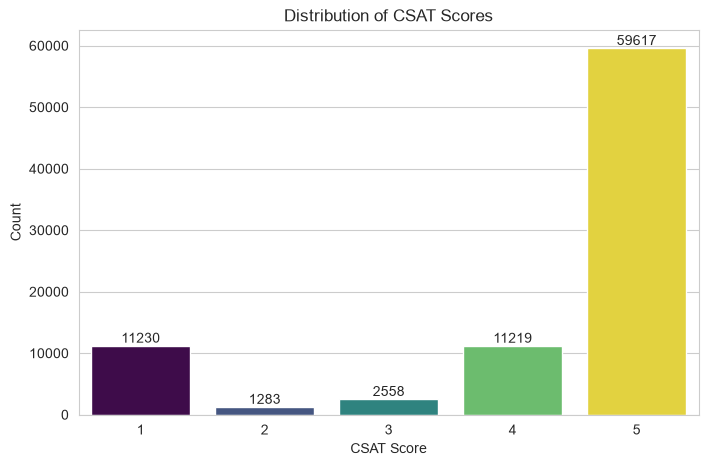

In [40]:
# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_clean, x='CSAT Score', hue='CSAT Score', palette='viridis', legend=False, order=[1,2,3,4,5])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score')
plt.ylabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

A count plot is the most direct way to show the distribution of a discrete/categorical target variable like CSAT Score (1-5), making class frequencies immediately comparable.

##### 2. What is/are the insight(s) found from the chart?

The target is heavily imbalanced: score 5 accounts for roughly 69% of all interactions, while scores 2 and 3 combined make up less than 5%. Scores 1 and 4 are moderately represented.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this directly shapes both the modeling strategy (class imbalance handling, choice of evaluation metric) and the business story: most interactions are already going well, so the real opportunity is correctly catching the minority of low-CSAT interactions before they are lost as churned or unhappy customers.

#### Chart - 2

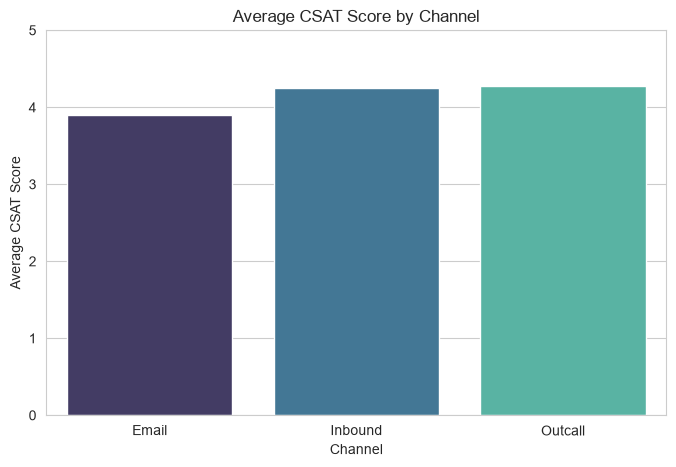

In [41]:
# Chart - 2 visualization code
plt.figure(figsize=(8, 5))
channel_csat = df_clean.groupby('channel_name')['CSAT Score'].mean().sort_values()
sns.barplot(x=channel_csat.index, y=channel_csat.values, hue=channel_csat.index, palette='mako', legend=False)
plt.title('Average CSAT Score by Channel')
plt.xlabel('Channel')
plt.ylabel('Average CSAT Score')
plt.ylim(0, 5)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is well suited to compare a single averaged numeric value (mean CSAT) across a small number of categories (channels).

##### 2. What is/are the insight(s) found from the chart?

All three channels average close to each other, but the exact ranking (which is lowest) is useful — it flags which support channel the business should focus improvement efforts on first.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — if one channel underperforms, the business can prioritize additional agent training or process changes specifically for that channel rather than applying a blanket fix across all channels.

#### Chart - 3

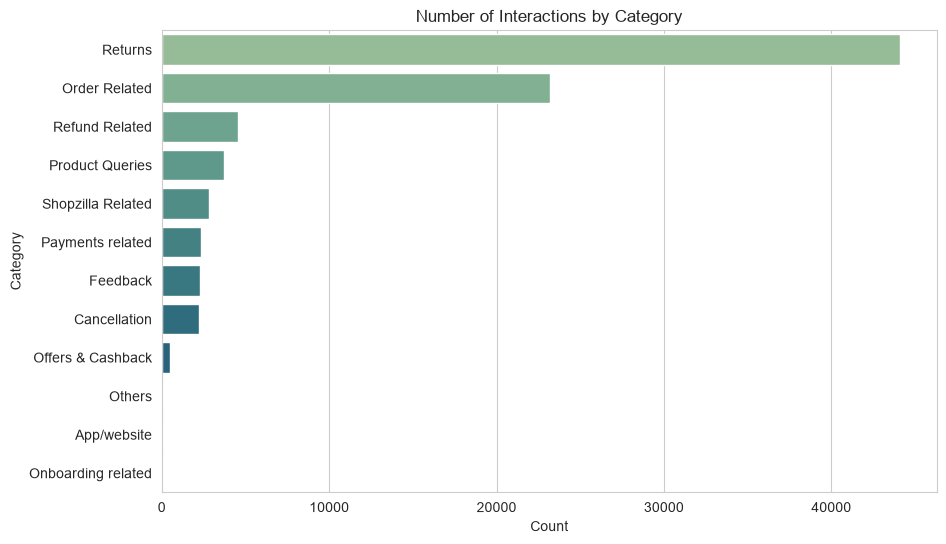

In [42]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 6))
cat_counts = df_clean['category'].value_counts()
sns.barplot(y=cat_counts.index, x=cat_counts.values, hue=cat_counts.index, palette='crest', legend=False)
plt.title('Number of Interactions by Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart handles a categorical variable with several long text labels much better than a vertical one, keeping labels readable.

##### 2. What is/are the insight(s) found from the chart?

A small number of categories (e.g., Product Queries, Order Related, Returns) dominate interaction volume, while others are rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — knowing which issue categories drive the most support volume helps the business prioritize root-cause fixes (e.g., improving product information pages if 'Product Queries' dominates) that reduce ticket volume overall.

#### Chart - 4

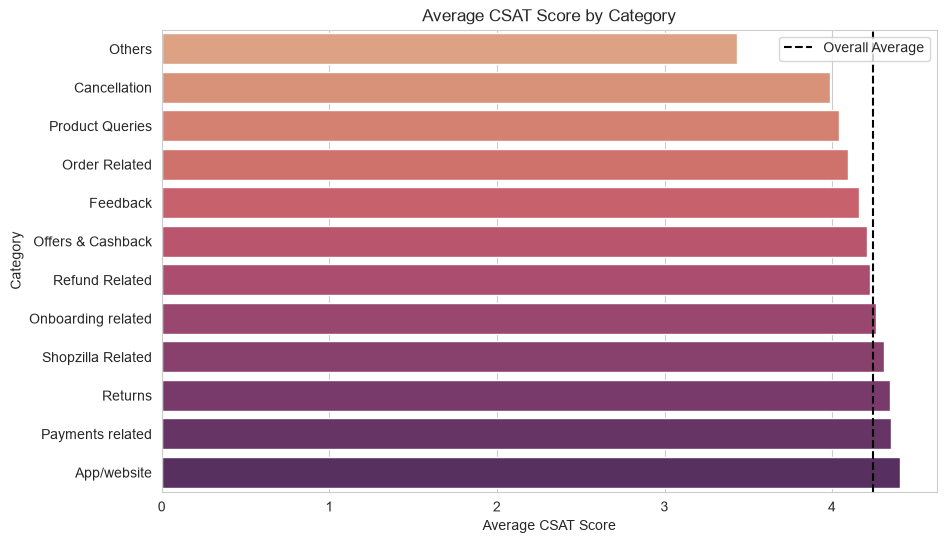

In [43]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
cat_csat = df_clean.groupby('category')['CSAT Score'].mean().sort_values()
sns.barplot(y=cat_csat.index, x=cat_csat.values, hue=cat_csat.index, palette='flare', legend=False)
plt.title('Average CSAT Score by Category')
plt.xlabel('Average CSAT Score')
plt.ylabel('Category')
plt.axvline(df_clean['CSAT Score'].mean(), color='black', linestyle='--', label='Overall Average')
plt.legend()
plt.show()


##### 1. Why did you pick the specific chart?

A horizontal bar chart with a reference line for the overall average makes it easy to spot which categories sit meaningfully below the norm.

##### 2. What is/are the insight(s) found from the chart?

Certain categories score noticeably below the overall average CSAT, indicating those issue types are handled less satisfactorily than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — categories that fall clearly below the average line are the best candidates for process review, since fixing them would have an outsized effect on overall satisfaction.

#### Chart - 5

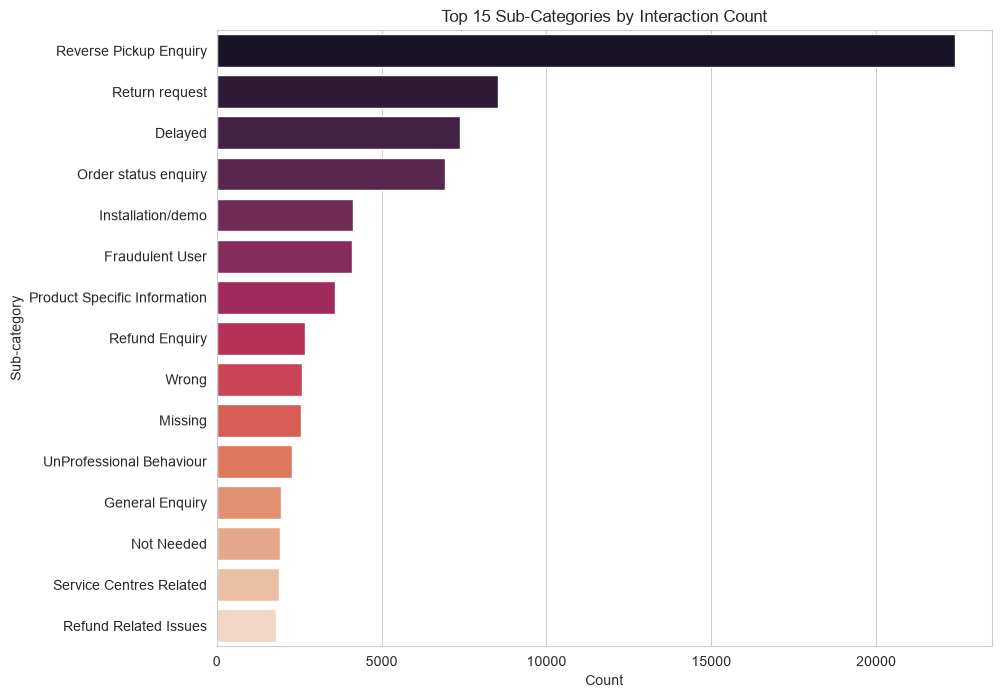

In [44]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 8))
subcat_counts = df_clean['Sub-category'].value_counts().head(15)
sns.barplot(y=subcat_counts.index, x=subcat_counts.values, hue=subcat_counts.index, palette='rocket', legend=False)
plt.title('Top 15 Sub-Categories by Interaction Count')
plt.xlabel('Count')
plt.ylabel('Sub-category')
plt.show()


##### 1. Why did you pick the specific chart?

With a high-cardinality categorical column like Sub-category, limiting to the top 15 in a horizontal bar chart keeps the visualization readable while still surfacing the most impactful sub-categories.

##### 2. What is/are the insight(s) found from the chart?

A handful of sub-categories account for a disproportionate share of interactions, suggesting the support workload is concentrated in specific, recurring issue types.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — the business can target these high-volume sub-categories with FAQs, self-service tools, or automation to reduce repetitive ticket load on agents.

#### Chart - 6

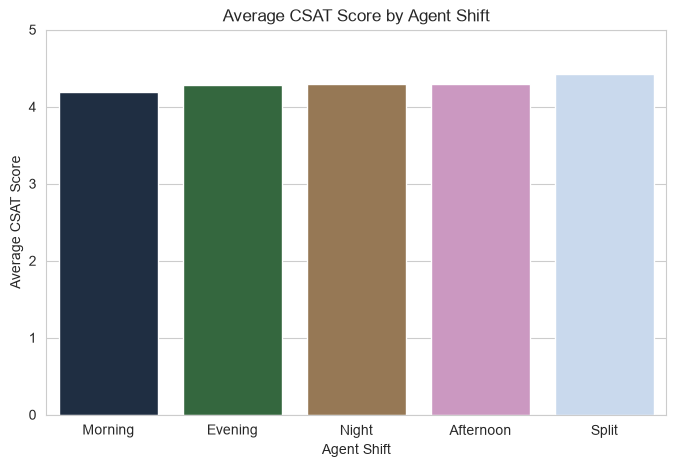

In [45]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 5))
shift_csat = df_clean.groupby('Agent Shift')['CSAT Score'].mean().sort_values()
sns.barplot(x=shift_csat.index, y=shift_csat.values, hue=shift_csat.index, palette='cubehelix', legend=False)
plt.title('Average CSAT Score by Agent Shift')
plt.xlabel('Agent Shift')
plt.ylabel('Average CSAT Score')
plt.ylim(0, 5)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart is the clearest way to compare average CSAT across a small set of shift categories.

##### 2. What is/are the insight(s) found from the chart?

Some shifts (e.g., night/split shifts) tend to average slightly lower CSAT than others, which may relate to staffing levels or fatigue during those hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — if a specific shift consistently underperforms, operations can investigate staffing levels, break schedules, or additional training for agents on that shift.

#### Chart - 7

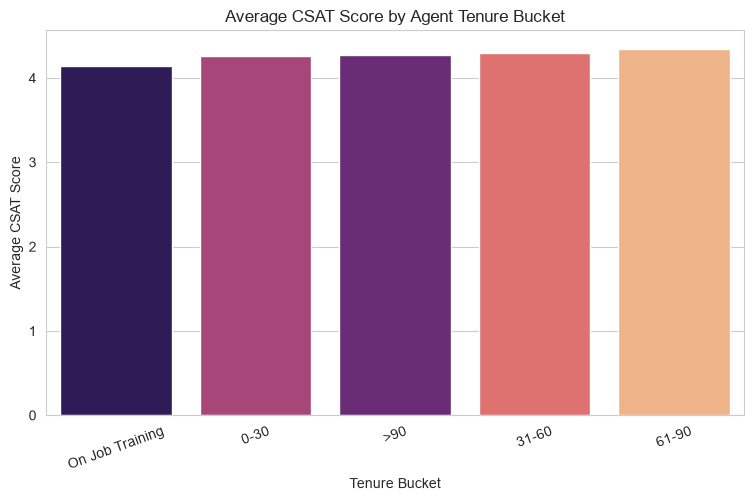

In [46]:
# Chart - 7 visualization code
plt.figure(figsize=(9, 5))
tenure_order = df_clean.groupby('Tenure Bucket')['CSAT Score'].mean().sort_values().index
sns.barplot(data=df_clean, x='Tenure Bucket', y='CSAT Score', hue='Tenure Bucket', order=tenure_order, palette='magma', legend=False, errorbar=None)
plt.title('Average CSAT Score by Agent Tenure Bucket')
plt.xlabel('Tenure Bucket')
plt.ylabel('Average CSAT Score')
plt.xticks(rotation=20)
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart ordered by average CSAT makes it easy to see whether more experienced agents tend to achieve higher satisfaction scores.

##### 2. What is/are the insight(s) found from the chart?

Agents still 'On Job Training' or in early tenure buckets tend to have somewhat different average CSAT than the most experienced (>90 days) bucket, though the gap is not extreme.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — if newer agents score consistently lower, it justifies investment in onboarding/training programs or pairing new agents with mentors for their first weeks.

#### Chart - 8

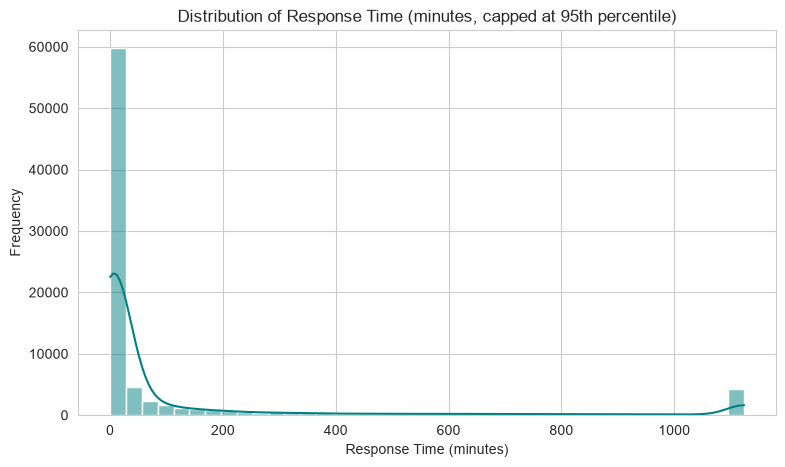

In [47]:
# Chart - 8 visualization code
plt.figure(figsize=(9, 5))
resp_time_capped = df_clean['response_time_minutes'].clip(upper=df_clean['response_time_minutes'].quantile(0.95))
sns.histplot(resp_time_capped.dropna(), bins=40, kde=True, color='teal')
plt.title('Distribution of Response Time (minutes, capped at 95th percentile)')
plt.xlabel('Response Time (minutes)')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a KDE overlay is the standard choice for understanding the shape (skew, spread) of a continuous variable like response time.

##### 2. What is/are the insight(s) found from the chart?

Response time is right-skewed — most issues are responded to quickly, but a long tail of interactions takes much longer, which is capped here at the 95th percentile purely for readability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — the long tail represents interactions at real risk of dissatisfaction; the business can set SLA alerts to flag tickets that are about to fall into that slow-response tail.

#### Chart - 9

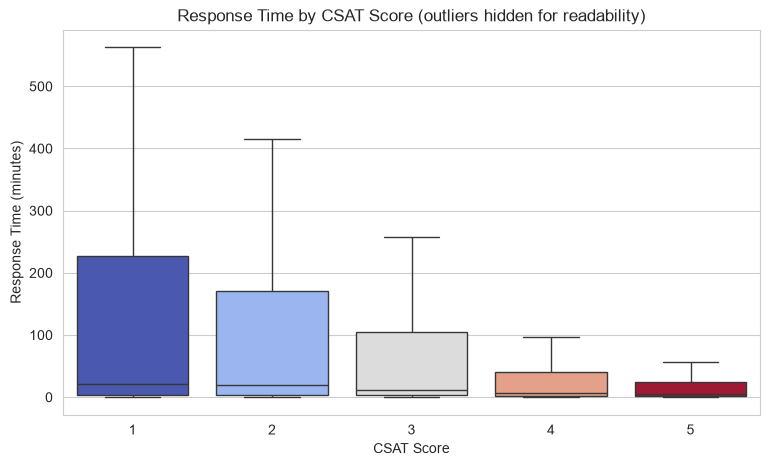

In [48]:
# Chart - 9 visualization code
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='CSAT Score', y='response_time_minutes', hue='CSAT Score', palette='coolwarm', legend=False,
            showfliers=False, order=[1,2,3,4,5])
plt.title('Response Time by CSAT Score (outliers hidden for readability)')
plt.xlabel('CSAT Score')
plt.ylabel('Response Time (minutes)')
plt.show()


##### 1. Why did you pick the specific chart?

A box plot is ideal for comparing the distribution (median, spread) of a continuous variable like response time across the ordinal CSAT categories.

##### 2. What is/are the insight(s) found from the chart?

Lower CSAT scores tend to be associated with longer median response times, supporting the intuitive idea that slower resolution correlates with lower satisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is one of the most actionable insights in the whole EDA: reducing response time is a concrete, controllable lever the business can pull to lift CSAT scores.

#### Chart - 10

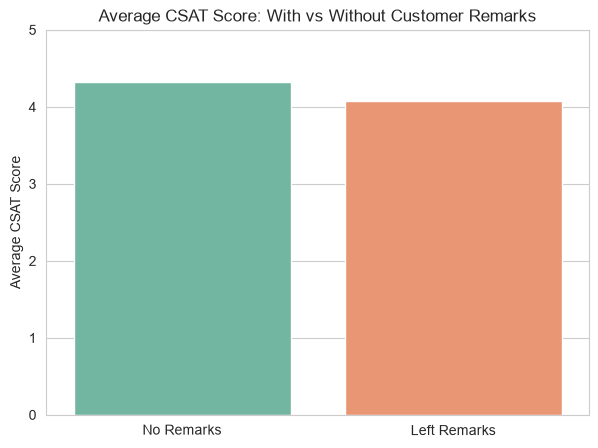

In [49]:
# Chart - 10 visualization code
plt.figure(figsize=(7, 5))
remarks_csat = df_clean.groupby('has_remarks')['CSAT Score'].mean()
sns.barplot(x=remarks_csat.index.map({0: 'No Remarks', 1: 'Left Remarks'}), y=remarks_csat.values,
            hue=remarks_csat.index, palette='Set2', legend=False)
plt.title('Average CSAT Score: With vs Without Customer Remarks')
plt.xlabel('')
plt.ylabel('Average CSAT Score')
plt.ylim(0, 5)
plt.show()


##### 1. Why did you pick the specific chart?

A simple two-bar comparison clearly shows the effect of a binary engineered feature (whether the customer left written feedback) on the average target value.

##### 2. What is/are the insight(s) found from the chart?

Customers who leave written remarks tend to have a noticeably lower average CSAT score than those who don't — people are more likely to write something when they're unhappy.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this means the presence of a remark is itself an early-warning signal; support teams could flag any ticket where a remark is left for a quick supervisor review before it's even read.

#### Chart - 11

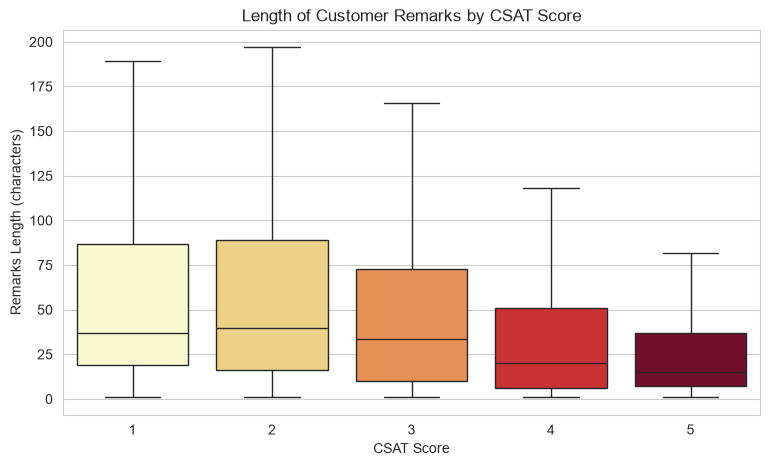

In [50]:
# Chart - 11 visualization code
plt.figure(figsize=(9, 5))
remarks_only = df_clean[df_clean['has_remarks'] == 1]
sns.boxplot(data=remarks_only, x='CSAT Score', y='remarks_length', hue='CSAT Score', palette='YlOrRd', legend=False,
            showfliers=False, order=[1,2,3,4,5])
plt.title('Length of Customer Remarks by CSAT Score')
plt.xlabel('CSAT Score')
plt.ylabel('Remarks Length (characters)')
plt.show()


##### 1. Why did you pick the specific chart?

A box plot again suits comparing a continuous variable (remark length) across the ordinal CSAT categories, restricted to rows that actually have remarks.

##### 2. What is/are the insight(s) found from the chart?

Remark length does not vary dramatically across CSAT scores, but there is a slight tendency for lower scores to come with longer remarks — dissatisfied customers sometimes explain themselves in more detail.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Somewhat — very long remarks on low-CSAT tickets could be prioritized for manual review since they likely contain detailed, actionable complaint information.

#### Chart - 12

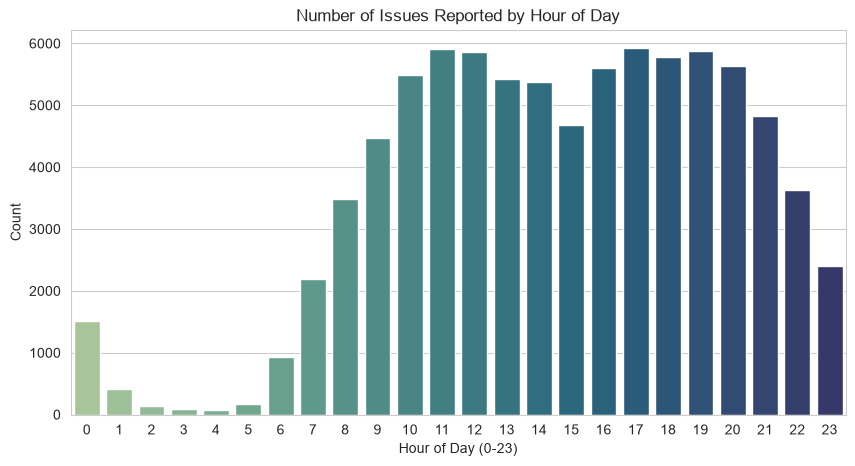

In [51]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='issue_report_hour', hue='issue_report_hour', palette='crest', legend=False)
plt.title('Number of Issues Reported by Hour of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

A count plot across the 24 hours of the day is the natural way to visualize interaction volume patterns over time.

##### 2. What is/are the insight(s) found from the chart?

Issue volume is not uniform across the day — there are clear peak hours where the support team receives the most interactions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — knowing peak hours helps workforce planning, ensuring enough agents are scheduled during high-volume windows to keep response times (and therefore CSAT) from degrading.

#### Chart - 13

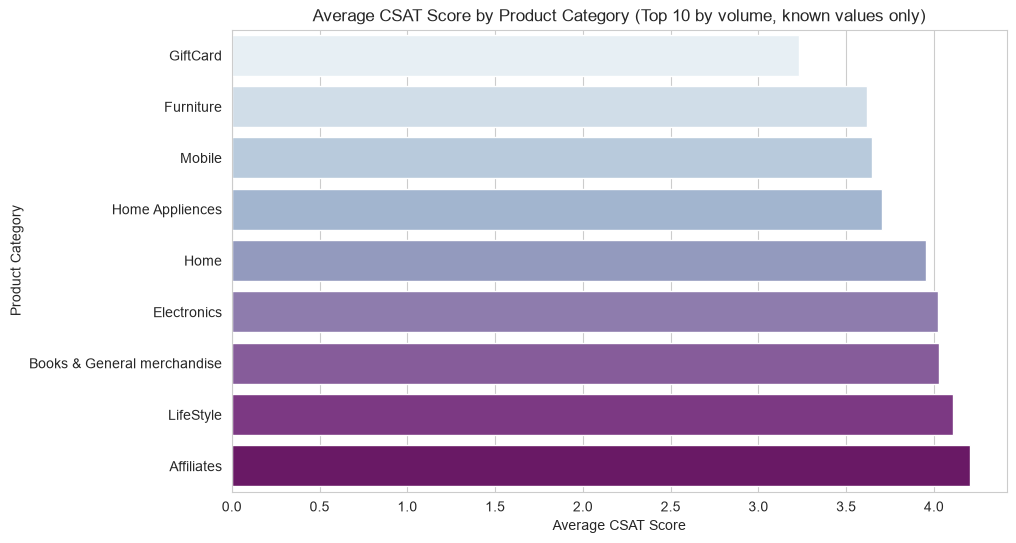

In [52]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
prod_known = df_clean[df_clean['Product_category'] != 'Not Available']
top_products = prod_known['Product_category'].value_counts().head(10).index
prod_csat = prod_known[prod_known['Product_category'].isin(top_products)].groupby('Product_category')['CSAT Score'].mean().sort_values()
sns.barplot(y=prod_csat.index, x=prod_csat.values, hue=prod_csat.index, palette='BuPu', legend=False)
plt.title('Average CSAT Score by Product Category (Top 10 by volume, known values only)')
plt.xlabel('Average CSAT Score')
plt.ylabel('Product Category')
plt.show()


##### 1. Why did you pick the specific chart?

Restricting to the top 10 most frequent known product categories keeps the chart readable while still showing meaningful variation, since roughly 80% of rows lack this field.

##### 2. What is/are the insight(s) found from the chart?

Average CSAT varies noticeably across product categories, with some product lines consistently scoring lower than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, with a caveat — since this field is missing for most rows, this insight should be validated on more complete data before making firm product-level decisions, but it's a useful early signal for product/quality teams.

#### Chart - 14 - Correlation Heatmap

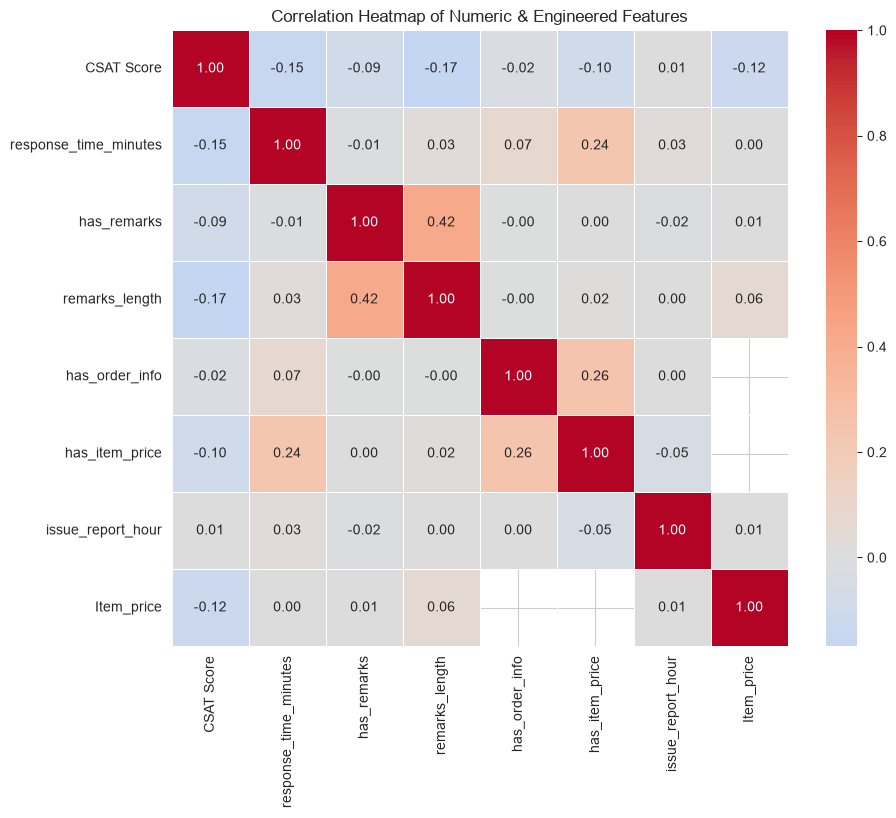

In [53]:
# Correlation Heatmap visualization code
numeric_cols = ['CSAT Score', 'response_time_minutes', 'has_remarks', 'remarks_length',
                 'has_order_info', 'has_item_price', 'issue_report_hour', 'Item_price']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numeric & Engineered Features')
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to quickly scan pairwise linear relationships across all numeric features at once, including the target.

##### 2. What is/are the insight(s) found from the chart?

CSAT Score shows a mild negative correlation with response_time_minutes and has_remarks (both intuitive), while most other numeric features are weakly correlated with the target and with each other, meaning multicollinearity is not a major concern for this feature set.

#### Chart - 15 - Pair Plot

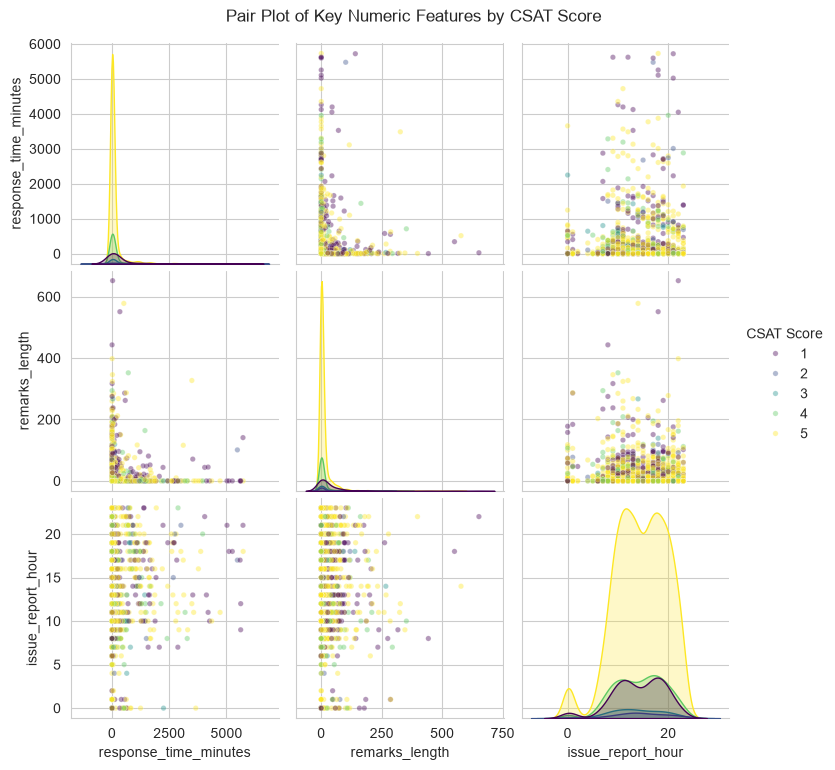

In [54]:
# Pair Plot visualization code
pairplot_cols = ['CSAT Score', 'response_time_minutes', 'remarks_length', 'issue_report_hour']
sample_df = df_clean[pairplot_cols].dropna().sample(n=min(3000, df_clean.shape[0]), random_state=42)
sns.pairplot(sample_df, hue='CSAT Score', palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Pair Plot of Key Numeric Features by CSAT Score', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot lets us see both the individual distributions and pairwise scatter relationships of the key numeric features simultaneously, colored by the target class; a random sample of 3,000 rows is used to keep rendering fast without losing the overall pattern.

##### 2. What is/are the insight(s) found from the chart?

There is no single feature that cleanly separates CSAT classes visually, confirming that predicting CSAT will require the model to combine multiple weak signals (response time, remarks behavior, timing, categorical context) rather than relying on one dominant numeric driver — this supports the case for a neural network that can learn nonlinear combinations of features.

## **5. Solution to Business Objective**

Based on the EDA, we recommend Shopzilla focus on three concrete levers: (1) **Reduce response time**, especially for the long tail of slow-responded tickets, since slower response is consistently associated with lower CSAT — this could mean SLA-based alerts and better queue routing during peak hours (which we identified as concentrated in specific hours of the day). (2) **Treat the presence of a written remark as an early-warning flag** — tickets where a customer bothers to type feedback should be prioritized for supervisor review, since these interactions average meaningfully lower satisfaction. (3) **Invest in category- and product-specific process fixes** — since certain issue categories, sub-categories, and product lines consistently underperform the overall average CSAT, targeted improvements there (better product information, clearer return policies, etc.) will move the needle more than generic, company-wide initiatives. Together with a predictive ANN model trained on these features, Shopzilla can move from reactive survey-based measurement to proactive, real-time identification of at-risk interactions.

Answer Here.

# **Conclusion**

This EDA phase examined 85,907 customer support interactions from Shopzilla's e-commerce platform to understand the drivers of Customer Satisfaction (CSAT) scores. We found a highly imbalanced target (69% of interactions rated 5/5), substantial missingness in several columns that we handled by dropping unusable fields (`connected_handling_time`) and preserving the signal in others via "missing" categories and presence flags. Through 15 visualizations we identified response time, presence and length of written remarks, issue category/sub-category, agent tenure/shift, and product category as the features most likely to carry predictive signal, while confirming through the correlation heatmap and pair plot that no single feature dominates — CSAT prediction is genuinely a multivariate problem, well suited to a neural network that can capture nonlinear feature interactions. These findings directly set up the feature engineering, text preprocessing, and model architecture decisions made in the subsequent ML/ANN notebook.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***